In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path

# Load the data

In [5]:
# select the experiments for which you want to analyse data
experiment_ids = [
    "test_20260207_144528",
    "test_20260129_225813",
]

In [40]:
# set the paths
root_path = Path(globals()['_dh'][0]).parent

all_iteration_data = []
all_agent_data = []
configs = {}
for experiment_id in experiment_ids:

    results_path = root_path / 'results' / experiment_id
    
    # read the number of simulations from the config file
    with open(results_path / 'config_used.yaml', "r") as f:
        config = yaml.safe_load(f)
    n_sims = config['experiment']['n_simulations']

    # read the results data for all simulations
    iteration_histories = [pd.read_csv(results_path / 'data' / f'iteration_history_{sim+1}.csv')
                           for sim in range(n_sims)]
    
    agents_histories = [pd.read_csv(results_path / 'data' / f'agent_histories_{sim+1}.csv')
                        for sim in range(n_sims)]

    # combine multiple simulations into a single dataframe for this experiment
    df_data = pd.concat(
        [df.assign(sim=i+1) for i, df in enumerate(iteration_histories)],
        ignore_index=True
    )
    df_data_agents = pd.concat(
        [df.assign(sim=i+1) for i, df in enumerate(agents_histories)],
        ignore_index=True
    )

    # add experiment identifier
    df_data['experiment_id'] = experiment_id
    df_data_agents['experiment_id'] = experiment_id

    # append to the list
    all_iteration_data.append(df_data)
    all_agent_data.append(df_data_agents)

    # store experiment configs
    configs[experiment_id] = config.copy()

# combine all experiments into single dataframes
df_data_all = pd.concat(all_iteration_data, ignore_index=True)
df_data_agents_all = pd.concat(all_agent_data, ignore_index=True)

print(f"Combined iteration data shape: {df_data_iter.shape}")
print(f"Combined agent data shape: {df_data_agents.shape}")
print(f"Experiments: {df_data_iter['experiment'].unique()}")
print(f"Simulations per experiment: \n{df_data_iter.groupby('experiment')['sim'].nunique()}")

Combined iteration data shape: (146, 14)
Combined agent data shape: (14, 10)
Experiments: ['test_20260207_144528' 'test_20260129_225813']
Simulations per experiment: 
experiment
test_20260129_225813    1
test_20260207_144528    2
Name: sim, dtype: int64


# Calculate the Equilibrium Price/Quantity for each experiment

In [38]:
def find_equilibrium(supply, demand, flat_threshold=1e-10):
    """
    Find equilibrium quantity and price where demand >= supply.
    
    Parameters:
        supply: array of supply prices at each quantity
        demand: array of demand prices at each quantity
        flat_threshold: tolerance for considering a curve "flat"
    
    Returns:
        q_eq: equilibrium quantity (number of trades)
        p_eq: equilibrium price
        p_supply: supply price at last trade
        p_demand: demand price at last trade
    """
    supply = np.asarray(supply)
    demand = np.asarray(demand)
    
    n = min(len(supply), len(demand))
    
    # Find last index where demand >= supply
    viable_mask = demand[:n] >= supply[:n]
    
    if not viable_mask.any():
        return 0, None, None, None
    
    last_idx = np.flatnonzero(viable_mask)[-1]
    next_idx = last_idx + 1
    
    q_eq = last_idx + 1
    p_supply = supply[last_idx]
    p_demand = demand[last_idx]
    
    # Check what happens at the next quantity unit
    has_next_supply = next_idx < len(supply)
    has_next_demand = next_idx < len(demand)
    
    # Determine price based on curve behavior at equilibrium
    if not has_next_supply:
        # Supply is vertical (ran out) - price based on demand side
        p_eq = (p_demand + demand[next_idx]) / 2 if has_next_demand else p_demand
    elif not has_next_demand:
        # Demand is vertical (ran out) - price based on supply side
        p_eq = (p_supply + supply[next_idx]) / 2 if has_next_supply else p_supply
    elif abs(supply[next_idx] - p_supply) < flat_threshold:
        # Supply is flat (perfectly elastic) - use supply price
        p_eq = p_supply
    elif abs(demand[next_idx] - p_demand) < flat_threshold:
        # Demand is flat (perfectly elastic) - use demand price
        p_eq = p_demand
    else:
        # Both curves have slope - use midpoint
        p_eq = (p_supply + p_demand) / 2
    
    return q_eq, p_eq

In [42]:
equilibria = {}

# calculate theoretical equilibrium for each experiment
for experiment_id in experiment_ids:

    # generate the demand schedule
    demand = np.round(
        np.linspace(
            configs[experiment_id]["experiment"]["buyers"]["max"],
            configs[experiment_id]["experiment"]["buyers"]["min"],
            configs[experiment_id]["experiment"]["buyers"]["num"],
        ),
        2,
    )

    # generate the supply schedule
    supply = np.round(
        np.linspace(
            configs[experiment_id]["experiment"]["sellers"]["min"],
            configs[experiment_id]["experiment"]["sellers"]["max"],
            configs[experiment_id]["experiment"]["sellers"]["num"],
        ),
        2,
    )
    
    # calculate the equilibrium
    q_eq, p_eq = find_equilibrium(supply=supply, demand=demand)
    
    # store
    df_data_all.loc[df_data_all["experiment_id"]==experiment_id, "equilibrium_price"] = p_eq
    df_data_all.loc[df_data_all["experiment_id"]==experiment_id, "equilibrium_quantity"] = q_eq
    equilibria[experiment_id] = {"price": p_eq, "quantity": q_eq}

## Plot the Supply and Demand Curves

In [48]:
def plot_equilibrium(supply, demand, q_eq, p_eq, title=None, ax=None):
    """
    Visualize supply and demand curves with equilibrium point.
    
    Parameters:
        supply: array of supply prices at each quantity
        demand: array of demand prices at each quantity
        q_eq: equilibrium quantity
        p_eq: equilibrium price
        title: optional plot title
        ax: optional matplotlib axes (creates new figure if None)
    
    Returns:
        matplotlib axes object
    """
    supply = np.asarray(supply)
    demand = np.asarray(demand)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    quantities_supply = np.arange(len(supply)) + 1
    quantities_demand = np.arange(len(demand)) + 1
    
    ax.step(quantities_supply, supply, 'b-', where='pre', label='Supply', linewidth=2)
    ax.step(quantities_demand, demand, 'r-', where='pre', label='Demand', linewidth=2)
    
    y_max = max(supply[-1], demand[0]) * 1.2
    
    # Extend supply vertically upward
    ax.vlines(len(supply), supply[-1], y_max, colors='blue', linewidth=2)
    
    # Extend demand vertically downward
    ax.vlines(len(demand), demand[-1], 0, colors='red', linewidth=2)
    
    if q_eq > 0 and p_eq is not None:
        ax.plot(q_eq, p_eq, 'go', markersize=12,
                label=f'Equilibrium: Q={q_eq}, P={p_eq:.2f}', zorder=5)
        ax.axhline(p_eq, color='green', linestyle=':', alpha=0.5, linewidth=1.5)
        ax.axvline(q_eq, color='green', linestyle='--', alpha=0.5, linewidth=1.5)
    
    ax.set_xlabel('Quantity')
    ax.set_ylabel('Price')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_title(title or 'Supply and Demand - Equilibrium')
    ax.set_ylim(0, y_max)
    
    return ax

In [49]:
equilibria

{'test_20260207_144528': {'price': np.float64(1.5), 'quantity': np.int64(2)},
 'test_20260129_225813': {'price': np.float64(1.5), 'quantity': np.int64(2)}}

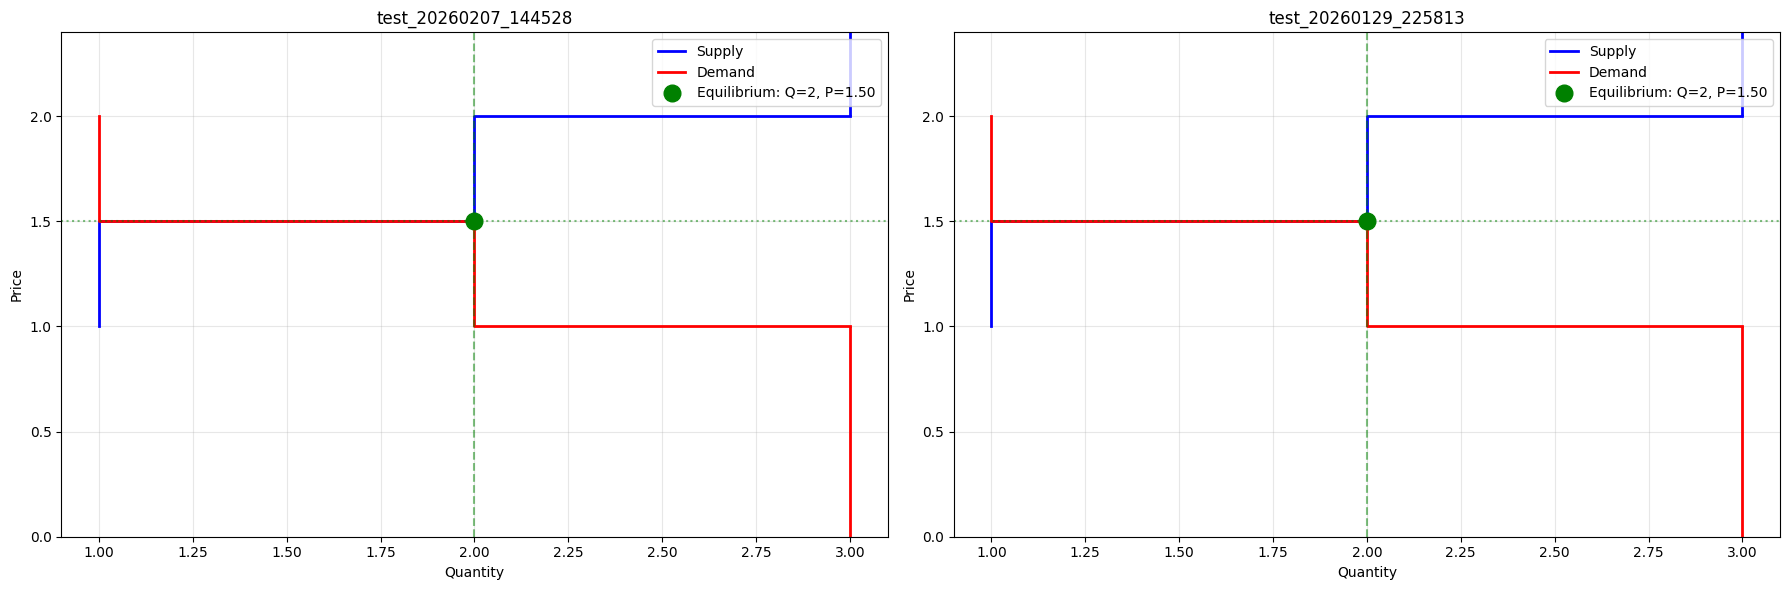

In [50]:
fig, axes = plt.subplots(1, len(experiment_ids), figsize=(9 * len(experiment_ids), 6))

# plot for each experiment
for experiment_id, ax in zip(experiment_ids, axes):

    # generate the demand schedule
    demand = np.round(
        np.linspace(
            configs[experiment_id]["experiment"]["buyers"]["max"],
            configs[experiment_id]["experiment"]["buyers"]["min"],
            configs[experiment_id]["experiment"]["buyers"]["num"],
        ),
        2,
    )

    # generate the supply schedule
    supply = np.round(
        np.linspace(
            configs[experiment_id]["experiment"]["sellers"]["min"],
            configs[experiment_id]["experiment"]["sellers"]["max"],
            configs[experiment_id]["experiment"]["sellers"]["num"],
        ),
        2,
    )

    # plot
    plot_equilibrium(supply, demand, equilibria[experiment_id]['quantity'], equilibria[experiment_id]['price'], title=experiment_id, ax=ax)


plt.tight_layout()
plt.show()

# Market-Wide Analysis

## Convergence to Theoretical Equilibrium

In [51]:
def calculate_coefficient_of_convergence(prices: np.ndarray, equilibrium_price: float):
    """Calculates the coefficient of convergene of prices to equilibrium (alpha) from the Smith (1962) paper.
    
    Parameters:
        prices: array of prices within a round
        equilibrium_price: theoretical equilibrium price    
    Returns:
        alpha: coefficient of convergene
    """
    squared_deviations = (prices - equilibrium_price)**2 
    var = squared_deviations.sum()/len(prices)
    std = var**0.5
    alpha = 100*std/equilibrium_price
    return alpha

df_transactions_all = df_data_all.loc[df_data_all['transaction_made']==True].reset_index()
coefficients_of_convergence = df_transactions_all.groupby(['experiment_id', 'sim', 'round'])['price'].agg(
    lambda prices: calculate_coefficient_of_convergence(prices.values, equilibrium_price=p_eq)
).reset_index(name='coefficient_of_convergence')

In [46]:
coefficients_of_convergence

,experiment_id,sim,round,coefficient_of_convergence
0,test_20260129_225813,1,1,23.570226
1,test_20260207_144528,1,1,23.570226
2,test_20260207_144528,1,2,24.037009
3,test_20260207_144528,1,3,24.037009
4,test_20260207_144528,1,4,33.333333
5,test_20260207_144528,1,5,33.333333
6,test_20260207_144528,2,1,23.570226
7,test_20260207_144528,2,2,23.570226
8,test_20260207_144528,2,3,0.000000
9,test_20260207_144528,2,4,0.000000


# Analyse Announcements

In [53]:
# summarize announcements in a single dataframe (collapse the responses into a single row)
df_announcements = df_data_all.groupby(
    ['experiment_id', 'sim', 'round', 'iteration', 'announcement_type', 'announcing_agent_id'],
    as_index=False, sort=False).agg({
                    'price': 'first',
                    'announcement_made': 'count',
                    'announcing_agent_reservation_price': 'first',
                    'transaction_made': 'last'})

df_announcements = df_announcements.rename(columns={'announcement_made': 'n_responses'})

# create masks
buy_mask = df_announcements['announcement_type'] == 'buy'
sell_mask = df_announcements['announcement_type'] == 'sell'

df_announcements

,experiment_id,sim,round,iteration,announcement_type,announcing_agent_id,price,n_responses,announcing_agent_reservation_price,transaction_made
0,test_20260207_144528,1,1,1,buy,0.0,1.0,1,1.0,True
1,test_20260207_144528,1,1,2,sell,4.0,1.5,1,1.5,True
2,test_20260207_144528,1,1,3,buy,1.0,1.4,1,1.5,False
3,test_20260207_144528,1,1,3,sell,5.0,2.0,1,2.0,False
4,test_20260207_144528,1,2,1,sell,5.0,2.0,1,2.0,True
...,...,...,...,...,...,...,...,...,...,...
68,test_20260129_225813,1,1,2,buy,0.0,1.0,2,1.0,False
69,test_20260129_225813,1,1,2,sell,3.0,2.0,2,1.0,False
70,test_20260129_225813,1,1,2,buy,1.0,1.5,2,1.5,True
71,test_20260129_225813,1,1,3,sell,3.0,2.0,1,1.0,False


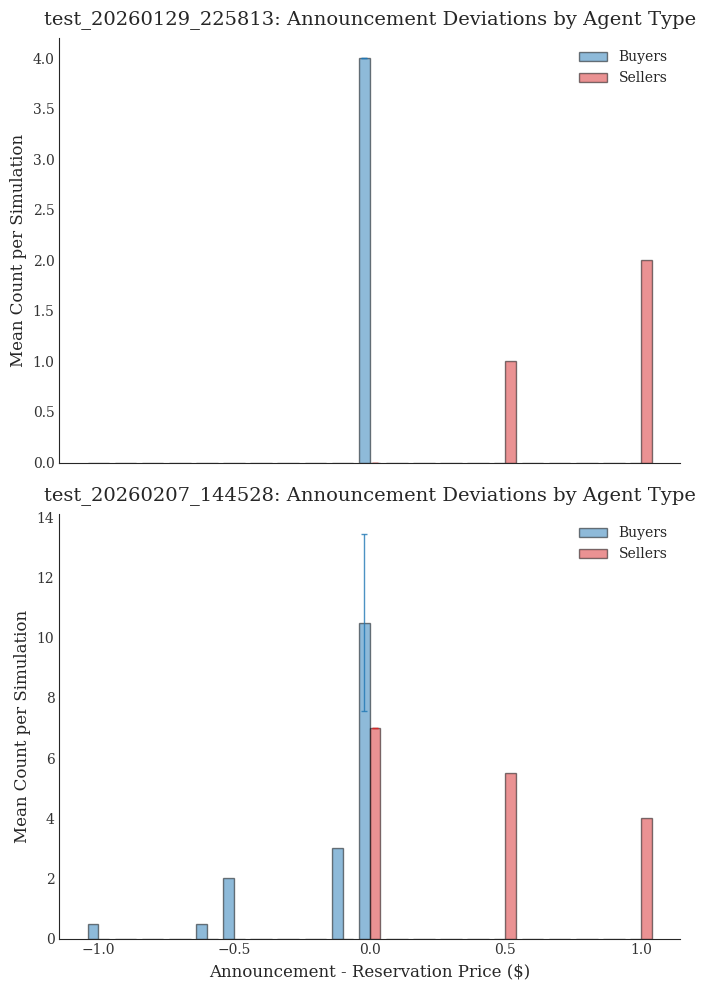

In [57]:
# Copy data and compute deviation
df_plot = df_announcements.copy()
df_plot['deviation'] = df_plot['price'] - df_plot['announcing_agent_reservation_price']

# Get unique experiments
experiments = sorted(df_plot['experiment_id'].unique())
n_experiments = len(experiments)

# Define bins symmetric around zero (computed across all data)
max_dev = np.max(np.abs(df_plot['deviation']))
num_bins = 20
bin_width = (2 * max_dev) / num_bins
bins = np.arange(-max_dev - bin_width/2, max_dev + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
zero_bin_idx = np.argmin(np.abs(bin_centers))

# Function to compute mean & CI across simulations
def compute_hist_ci(data, mask, value_col, bins):
    sims = data['sim'].unique()
    if len(sims) == 0:
        return np.zeros(len(bins)-1), np.zeros(len(bins)-1)
    counts_per_sim = []
    for sim_id in sims:
        vals = data.loc[(data['sim'] == sim_id) & mask, value_col]
        counts, _ = np.histogram(vals, bins=bins, density=False)
        counts_per_sim.append(counts)
    counts_per_sim = np.array(counts_per_sim)
    mean_counts = counts_per_sim.mean(axis=0)
    # CI is undefined with only 1 simulation — return zeros
    if len(sims) < 2:
        ci95 = np.zeros(len(bins)-1)
    else:
        se = counts_per_sim.std(axis=0, ddof=1) / np.sqrt(len(sims))
        ci95 = 1.96 * se
    return mean_counts, ci95

# --- Plot ---
sns.set_style("white")

# Create subplots: one per experiment
fig, axes = plt.subplots(n_experiments, 1, figsize=(7, 5*n_experiments), 
                         sharex=True, sharey=False)

# Handle case of single experiment
if n_experiments == 1:
    axes = [axes]

for idx, experiment_id in enumerate(experiments):
    ax = axes[idx]
    
    # Filter data for this experiment
    exp_data = df_plot[df_plot['experiment_id'] == experiment_id]
    buy_mask = exp_data['announcement_type'] == 'buy'
    sell_mask = exp_data['announcement_type'] == 'sell'
    
    # Compute histograms + CIs for this experiment
    buyers_mean, buyers_ci = compute_hist_ci(exp_data, buy_mask, 'deviation', bins)
    sellers_mean, sellers_ci = compute_hist_ci(exp_data, sell_mask, 'deviation', bins)
    
    # Set width and offset for side-by-side bars
    bar_width = bin_width * 0.4
    offset = bin_width * 0.2
    
    # Buyers (offset to the left)
    ax.bar(
        bin_centers - offset, buyers_mean,
        width=bar_width, color='#1f77b4', alpha=0.5,
        edgecolor='k', label='Buyers'
    )
    
    # Sellers (offset to the right)
    ax.bar(
        bin_centers + offset, sellers_mean,
        width=bar_width, color='#d62728', alpha=0.5,
        edgecolor='k', label='Sellers'
    )
    
    # Draw CI only for the 0 bin
    ax.errorbar(
        bin_centers[zero_bin_idx] - offset, buyers_mean[zero_bin_idx], 
        yerr=buyers_ci[zero_bin_idx],
        fmt='none', ecolor='#1f77b4', elinewidth=1, capsize=2, alpha=0.8
    )
    ax.errorbar(
        bin_centers[zero_bin_idx] + offset, sellers_mean[zero_bin_idx], 
        yerr=sellers_ci[zero_bin_idx],
        fmt='none', ecolor='#d62728', elinewidth=1, capsize=2, alpha=0.8
    )
    
    # Styling
    ax.set_ylabel("Mean Count per Simulation", fontsize=12, family='serif')
    ax.set_title(f"{experiment_id}: Announcement Deviations by Agent Type",
                 fontsize=14, family='serif', pad=10)
    
    ax.tick_params(axis='both', direction='in', labelsize=10, colors='#333333')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_family('serif')
    
    for side in ['top', 'right']:
        ax.spines[side].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    
    ax.legend(loc='upper right', frameon=False, prop={'family': 'serif', 'size': 10})
    ax.grid(False)

# Set x-label only on bottom plot
axes[-1].set_xlabel("Announcement - Reservation Price ($)", fontsize=12, family='serif')

fig.tight_layout()
plt.show()

In [58]:
def compute_deviation_metrics(df_announcements):
    """Compute summary metrics for announcement deviations."""
    
    results = []
    
    for experiment_id in df_announcements['experiment_id'].unique():
        exp_data = df_announcements[df_announcements['experiment_id'] == experiment_id]
        exp_data = exp_data.copy()
        exp_data['deviation'] = exp_data['price'] - exp_data['announcing_agent_reservation_price']
        
        # Overall metrics
        total_announcements = len(exp_data)
        zero_deviation = (exp_data['deviation'].abs() < 1e-6).sum()
        zero_rate = zero_deviation / total_announcements * 100
        
        # By type
        buyers = exp_data[exp_data['announcement_type'] == 'buy']
        sellers = exp_data[exp_data['announcement_type'] == 'sell']
        
        # Zero-deviation rates
        buyers_zero = (buyers['deviation'].abs() < 1e-6).sum() / len(buyers) * 100 if len(buyers) > 0 else 0
        sellers_zero = (sellers['deviation'].abs() < 1e-6).sum() / len(sellers) * 100 if len(sellers) > 0 else 0
        
        # Mean deviation (positive = asking/bidding above reservation)
        buyers_mean_dev = buyers['deviation'].mean() if len(buyers) > 0 else 0
        sellers_mean_dev = sellers['deviation'].mean() if len(sellers) > 0 else 0
        
        # Mean absolute deviation (distance from truthful)
        buyers_mad = buyers['deviation'].abs().mean() if len(buyers) > 0 else 0
        sellers_mad = sellers['deviation'].abs().mean() if len(sellers) > 0 else 0
             
        results.append({
            'experiment_id': experiment_id,
            'zero_rate_overall': zero_rate,
            'zero_rate_buyers': buyers_zero,
            'zero_rate_sellers': sellers_zero,
            'mean_dev_buyers': buyers_mean_dev,
            'mean_dev_sellers': sellers_mean_dev,
            'mad_buyers': buyers_mad,
            'mad_sellers': sellers_mad,
        })
    
    return pd.DataFrame(results)

# Compute metrics
metrics_df = compute_deviation_metrics(df_announcements)
print(metrics_df.to_string(index=False))

       experiment_id  zero_rate_overall  zero_rate_buyers  zero_rate_sellers  mean_dev_buyers  mean_dev_sellers  mad_buyers  mad_sellers
test_20260207_144528          53.030303         63.636364          42.424242        -0.127273          0.409091    0.127273     0.409091
test_20260129_225813          57.142857        100.000000           0.000000         0.000000          0.833333    0.000000     0.833333


SUMMARY METRICS WITH 95% CONFIDENCE INTERVALS

test_20260207_144528 (n=2 simulations):
  Zero-deviation rate - Buyers:   66.54% ± 37.58%
  Zero-deviation rate - Sellers:  44.42% ± 18.47%

test_20260129_225813 (n=1 simulations):
  Zero-deviation rate - Buyers:  100.00% ±  0.00%
  Zero-deviation rate - Sellers:   0.00% ±  0.00%


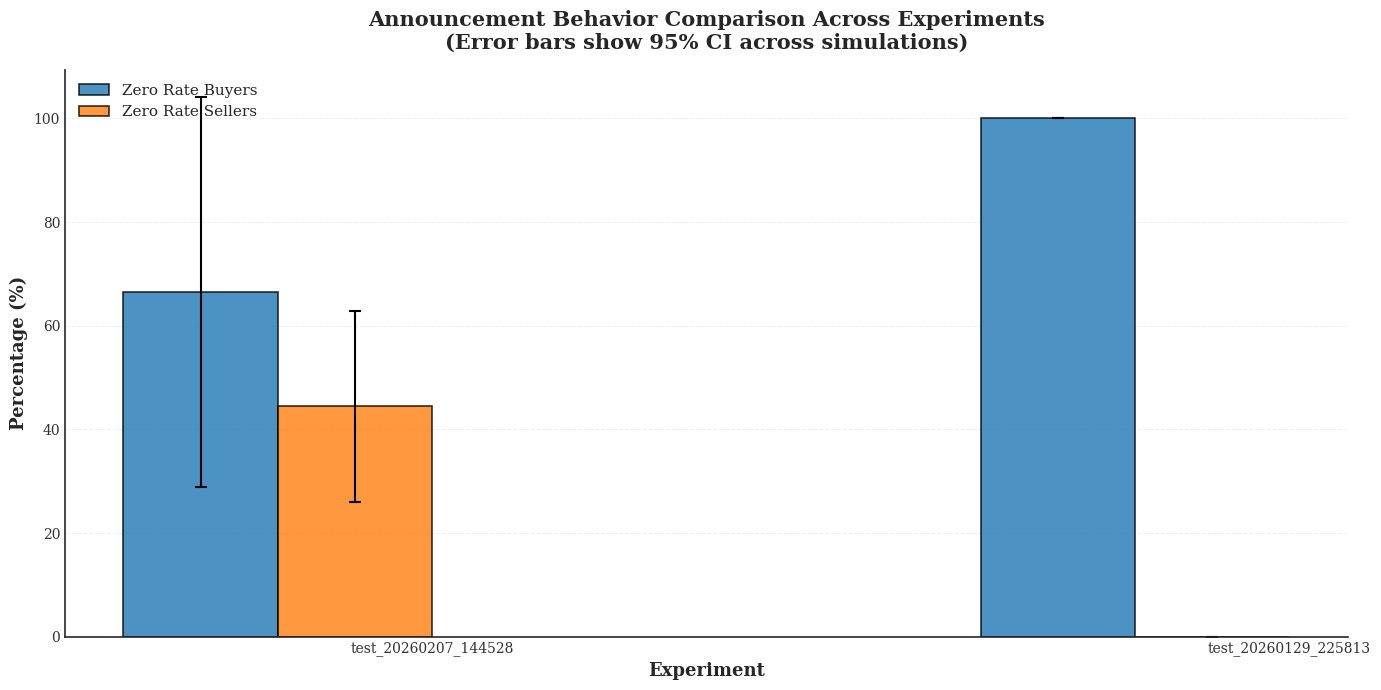

In [61]:
def compute_deviation_metrics_with_ci(df_announcements):
    """Compute summary metrics with 95% CI across simulations."""
    
    all_sim_results = []
    
    for experiment_id in df_announcements['experiment_id'].unique():
        exp_data = df_announcements[df_announcements['experiment_id'] == experiment_id]
        
        # Compute metrics for each simulation separately
        for sim_id in exp_data['sim'].unique():
            sim_data = exp_data[exp_data['sim'] == sim_id].copy()
            sim_data['deviation'] = sim_data['price'] - sim_data['announcing_agent_reservation_price']
            
            # Overall metrics
            total_announcements = len(sim_data)
            zero_deviation = (sim_data['deviation'].abs() < 1e-6).sum()
            zero_rate = zero_deviation / total_announcements * 100 if total_announcements > 0 else 0
            
            # By type
            buyers = sim_data[sim_data['announcement_type'] == 'buy']
            sellers = sim_data[sim_data['announcement_type'] == 'sell']
            
            # Zero-deviation rates
            buyers_zero = (buyers['deviation'].abs() < 1e-6).sum() / len(buyers) * 100 if len(buyers) > 0 else 0
            sellers_zero = (sellers['deviation'].abs() < 1e-6).sum() / len(sellers) * 100 if len(sellers) > 0 else 0
            
            # Mean deviation
            buyers_mean_dev = buyers['deviation'].mean() if len(buyers) > 0 else 0
            sellers_mean_dev = sellers['deviation'].mean() if len(sellers) > 0 else 0
            
            # Mean absolute deviation
            buyers_mad = buyers['deviation'].abs().mean() if len(buyers) > 0 else 0
            sellers_mad = sellers['deviation'].abs().mean() if len(sellers) > 0 else 0
            
            all_sim_results.append({
                'experiment_id': experiment_id,
                'sim': sim_id,
                'zero_rate_overall': zero_rate,
                'zero_rate_buyers': buyers_zero,
                'zero_rate_sellers': sellers_zero,
                'mean_dev_buyers': buyers_mean_dev,
                'mean_dev_sellers': sellers_mean_dev,
                'mad_buyers': buyers_mad,
                'mad_sellers': sellers_mad,
            })
    
    # Convert to DataFrame
    sim_results = pd.DataFrame(all_sim_results)
    
    # Compute mean and 95% CI for each experiment
    summary_results = []
    
    for experiment_id in sim_results['experiment_id'].unique():
        exp_sims = sim_results[sim_results['experiment_id'] == experiment_id]
        n_sims = len(exp_sims)
        
        
        result = {'experiment_id': experiment_id, 'n_sims': n_sims}
        
        # For each metric, compute mean and CI
        metrics = [col for col in sim_results.columns if col not in ['experiment_id', 'sim']]
        
        for metric in metrics:
            values = exp_sims[metric].values
            mean_val = values.mean()
            se = values.std(ddof=1) / np.sqrt(n_sims) if n_sims > 1 else 0
            ci95 = 1.96 * se
            
            result[f'{metric}_mean'] = mean_val
            result[f'{metric}_ci'] = ci95
        
        summary_results.append(result)
    
    return pd.DataFrame(summary_results), sim_results

# Compute metrics with CI
metrics_summary, metrics_by_sim = compute_deviation_metrics_with_ci(df_announcements)

# Print summary table
print("=" * 100)
print("SUMMARY METRICS WITH 95% CONFIDENCE INTERVALS")
print("=" * 100)
for _, row in metrics_summary.iterrows():
    print(f"\n{row['experiment_id']} (n={int(row['n_sims'])} simulations):")
    print(f"  Zero-deviation rate - Buyers:  {row['zero_rate_buyers_mean']:6.2f}% ± {row['zero_rate_buyers_ci']:5.2f}%")
    print(f"  Zero-deviation rate - Sellers: {row['zero_rate_sellers_mean']:6.2f}% ± {row['zero_rate_sellers_ci']:5.2f}%")
print("=" * 100)

# --- Visualization ---
metrics_to_plot = [
    ('zero_rate_buyers', 'Zero Rate Buyers'),
    ('zero_rate_sellers', 'Zero Rate Sellers'),
]

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(metrics_summary))
width = 0.18  # Width of each bar
multiplier = 0

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, (metric, label) in enumerate(metrics_to_plot):
    offset = width * multiplier
    means = metrics_summary[f'{metric}_mean']
    cis = metrics_summary[f'{metric}_ci']
    
    bars = ax.bar(x + offset, means, width, label=label,
                  color=colors[idx], alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Add error bars
    ax.errorbar(x + offset, means, yerr=cis, fmt='none', 
                ecolor='black', elinewidth=1.5, capsize=4, capthick=1.5)
    
    multiplier += 1

ax.set_xlabel('Experiment', fontsize=13, fontweight='bold', family='serif')
ax.set_ylabel('Percentage (%)', fontsize=13, fontweight='bold', family='serif')
ax.set_title('Announcement Behavior Comparison Across Experiments\n(Error bars show 95% CI across simulations)', 
             fontsize=15, fontweight='bold', family='serif', pad=15)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_summary['experiment_id'], fontsize=11, family='serif')
ax.legend(loc='upper left', frameon=False, prop={'family': 'serif', 'size': 11})
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)

# Style the spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Tick styling
ax.tick_params(axis='both', direction='in', labelsize=10, colors='#333333')
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')

plt.tight_layout()
plt.show()

SUMMARY METRICS WITH 95% CONFIDENCE INTERVALS

test_20260207_144528 (n=2 simulations):
  Mean absolute deviation - Buyers:   0.12% ±  0.10%
  Mean absolute deviation - Sellers:   0.39% ±  0.16%

test_20260129_225813 (n=1 simulations):
  Mean absolute deviation - Buyers:   0.00% ±  0.00%
  Mean absolute deviation - Sellers:   0.83% ±  0.00%


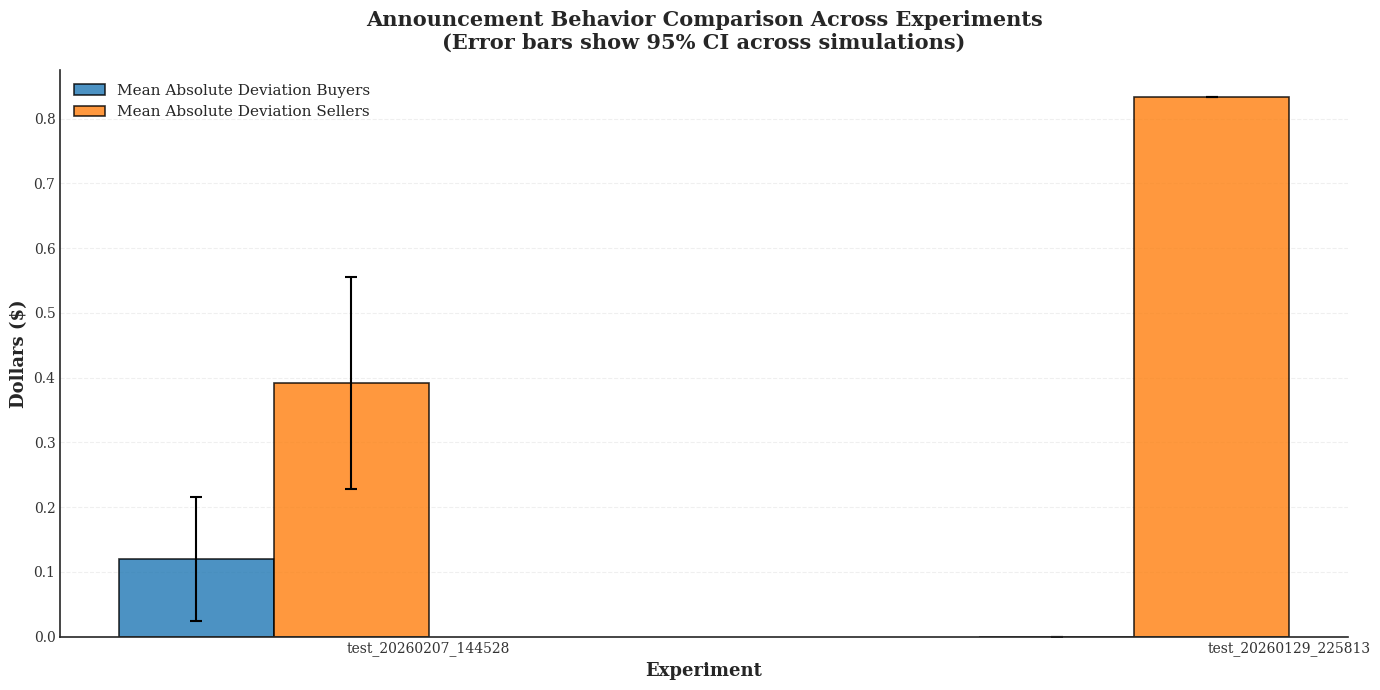

In [62]:
def compute_deviation_metrics_with_ci(df_announcements):
    """Compute summary metrics with 95% CI across simulations."""
    
    all_sim_results = []
    
    for experiment_id in df_announcements['experiment_id'].unique():
        exp_data = df_announcements[df_announcements['experiment_id'] == experiment_id]
        
        # Compute metrics for each simulation separately
        for sim_id in exp_data['sim'].unique():
            sim_data = exp_data[exp_data['sim'] == sim_id].copy()
            sim_data['deviation'] = sim_data['price'] - sim_data['announcing_agent_reservation_price']
            
            # Overall metrics
            total_announcements = len(sim_data)
            zero_deviation = (sim_data['deviation'].abs() < 1e-6).sum()
            zero_rate = zero_deviation / total_announcements * 100 if total_announcements > 0 else 0
            
            # By type
            buyers = sim_data[sim_data['announcement_type'] == 'buy']
            sellers = sim_data[sim_data['announcement_type'] == 'sell']
            
            # Zero-deviation rates
            buyers_zero = (buyers['deviation'].abs() < 1e-6).sum() / len(buyers) * 100 if len(buyers) > 0 else 0
            sellers_zero = (sellers['deviation'].abs() < 1e-6).sum() / len(sellers) * 100 if len(sellers) > 0 else 0
            
            # Mean deviation
            buyers_mean_dev = buyers['deviation'].mean() if len(buyers) > 0 else 0
            sellers_mean_dev = sellers['deviation'].mean() if len(sellers) > 0 else 0
            
            # Mean absolute deviation
            buyers_mad = buyers['deviation'].abs().mean() if len(buyers) > 0 else 0
            sellers_mad = sellers['deviation'].abs().mean() if len(sellers) > 0 else 0
            
            all_sim_results.append({
                'experiment_id': experiment_id,
                'sim': sim_id,
                'zero_rate_overall': zero_rate,
                'zero_rate_buyers': buyers_zero,
                'zero_rate_sellers': sellers_zero,
                'mean_dev_buyers': buyers_mean_dev,
                'mean_dev_sellers': sellers_mean_dev,
                'mad_buyers': buyers_mad,
                'mad_sellers': sellers_mad,
            })
    
    # Convert to DataFrame
    sim_results = pd.DataFrame(all_sim_results)
    
    # Compute mean and 95% CI for each experiment
    summary_results = []
    
    for experiment_id in sim_results['experiment_id'].unique():
        exp_sims = sim_results[sim_results['experiment_id'] == experiment_id]
        n_sims = len(exp_sims)
        
        
        result = {'experiment_id': experiment_id, 'n_sims': n_sims}
        
        # For each metric, compute mean and CI
        metrics = [col for col in sim_results.columns if col not in ['experiment_id', 'sim']]
        
        for metric in metrics:
            values = exp_sims[metric].values
            mean_val = values.mean()
            se = values.std(ddof=1) / np.sqrt(n_sims) if n_sims > 1 else 0
            ci95 = 1.96 * se
            
            result[f'{metric}_mean'] = mean_val
            result[f'{metric}_ci'] = ci95
        
        summary_results.append(result)
    
    return pd.DataFrame(summary_results), sim_results

# Compute metrics with CI
metrics_summary, metrics_by_sim = compute_deviation_metrics_with_ci(df_announcements)

# Print summary table
print("=" * 100)
print("SUMMARY METRICS WITH 95% CONFIDENCE INTERVALS")
print("=" * 100)
for _, row in metrics_summary.iterrows():
    print(f"\n{row['experiment_id']} (n={int(row['n_sims'])} simulations):")
    print(f"  Mean absolute deviation - Buyers: {row['mad_buyers_mean']:6.2f}% ± {row['mad_buyers_ci']:5.2f}%")
    print(f"  Mean absolute deviation - Sellers: {row['mad_sellers_mean']:6.2f}% ± {row['mad_sellers_ci']:5.2f}%")
print("=" * 100)

# --- Visualization ---
metrics_to_plot = [
    ('mad_buyers', 'Mean Absolute Deviation Buyers'),
    ('mad_sellers', 'Mean Absolute Deviation Sellers'),
]

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(metrics_summary))
width = 0.18  # Width of each bar
multiplier = 0

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, (metric, label) in enumerate(metrics_to_plot):
    offset = width * multiplier
    means = metrics_summary[f'{metric}_mean']
    cis = metrics_summary[f'{metric}_ci']
    
    bars = ax.bar(x + offset, means, width, label=label,
                  color=colors[idx], alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Add error bars
    ax.errorbar(x + offset, means, yerr=cis, fmt='none', 
                ecolor='black', elinewidth=1.5, capsize=4, capthick=1.5)
    
    multiplier += 1

ax.set_xlabel('Experiment', fontsize=13, fontweight='bold', family='serif')
ax.set_ylabel('Dollars ($)', fontsize=13, fontweight='bold', family='serif')
ax.set_title('Announcement Behavior Comparison Across Experiments\n(Error bars show 95% CI across simulations)', 
             fontsize=15, fontweight='bold', family='serif', pad=15)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_summary['experiment_id'], fontsize=11, family='serif')
ax.legend(loc='upper left', frameon=False, prop={'family': 'serif', 'size': 11})
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)

# Style the spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Tick styling
ax.tick_params(axis='both', direction='in', labelsize=10, colors='#333333')
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')

plt.tight_layout()
plt.show()